# Heart Disease Risk Prediction using Machine Learning
This project applies supervised machine learning techniques to predict cardiovascular disease risk using clinical patient data from the Cleveland Heart Disease dataset.

## Project Objective

The goal of this project is to develop a machine learning model capable of predicting the risk of heart disease using clinical patient data. The project utilizes the Cleveland Heart Disease dataset and applies classification algorithms including Logistic Regression and Random Forest.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Dataset Information

Dataset: Cleveland Heart Disease Dataset

Features include:
- Age
- Chest pain type
- Cholesterol
- Blood pressure
- Maximum heart rate
- ECG-related parameters

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [7]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [8]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [9]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand feature distributions, identify relationships between variables, and analyze patterns associated with heart disease risk.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

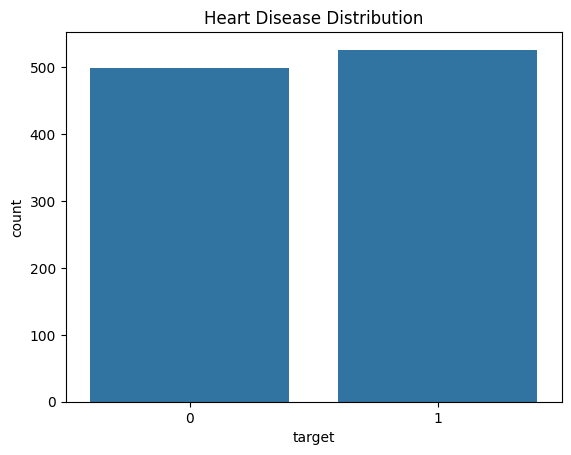

In [12]:
sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.show()

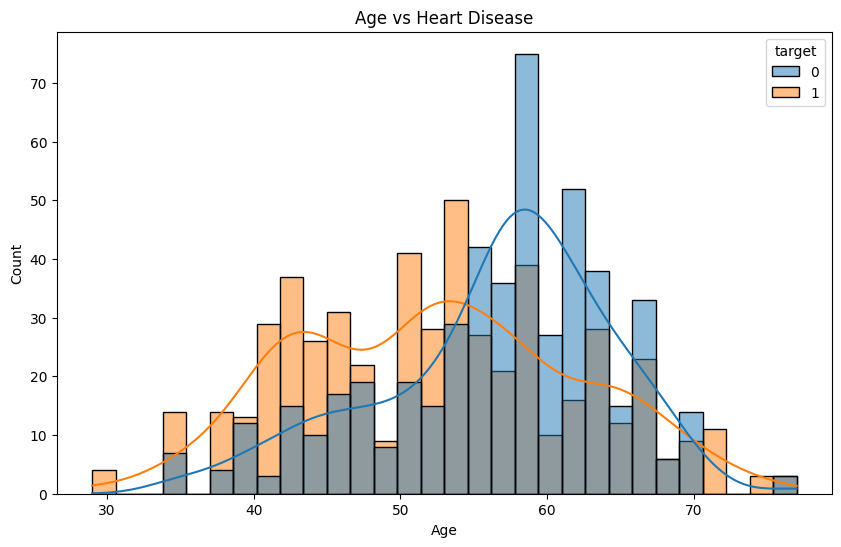

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='age',
    hue='target',
    bins=30,
    kde=True
)

plt.title("Age vs Heart Disease")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

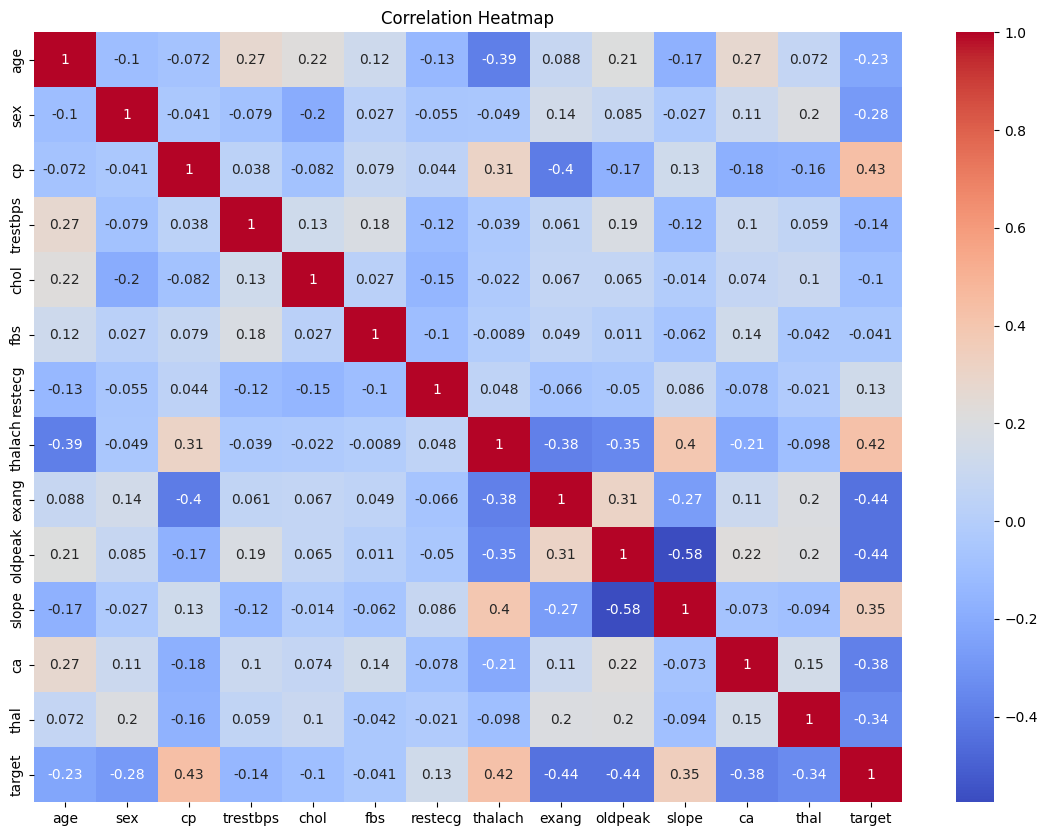

In [15]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Data Preprocessing

Steps performed:
- Missing value analysis
- Train-test split
- Feature scaling using StandardScaler

In [16]:
X = df.drop('target', axis=1)

y = df['target']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(820, 13)
(205, 13)
(820,)
(205,)


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
X_train = scaler.fit_transform(X_train)

In [24]:
X_test = scaler.transform(X_test)

## Machine Learning Model Training

Two classification algorithms were implemented:
- Logistic Regression
- Random Forest Classifier

The models were trained to predict cardiovascular disease risk using patient clinical features.

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model = LogisticRegression()

In [28]:
model.fit(X_train, y_train)

LogisticRegression()

In [29]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

## Model Evaluation Results

The trained models were evaluated using:
- Accuracy score
- Confusion matrix
- Classification report
- Precision, Recall, and F1-score

In [32]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7951219512195122


In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[73 29]
 [13 90]]


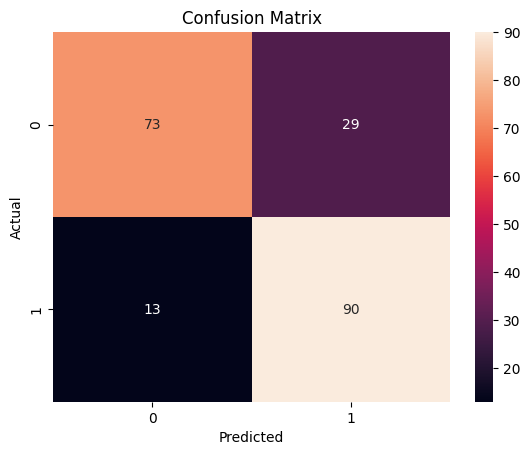

In [35]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [36]:
from sklearn.metrics import classification_report

In [37]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
rf_predictions = rf_model.predict(X_test)

## Model Evaluation Results

The machine learning models were evaluated using multiple performance metrics including:
- Accuracy score
- Confusion matrix
- Precision
- Recall
- F1-score

These metrics help assess the effectiveness of the models in predicting cardiovascular disease risk.

In [42]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9853658536585366


In [43]:
importance = rf_model.feature_importances_

In [44]:
features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [45]:
features = features.sort_values(
    by='Importance',
    ascending=False
)

In [46]:
print(features)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model to identify the most influential clinical predictors contributing to heart disease risk prediction.

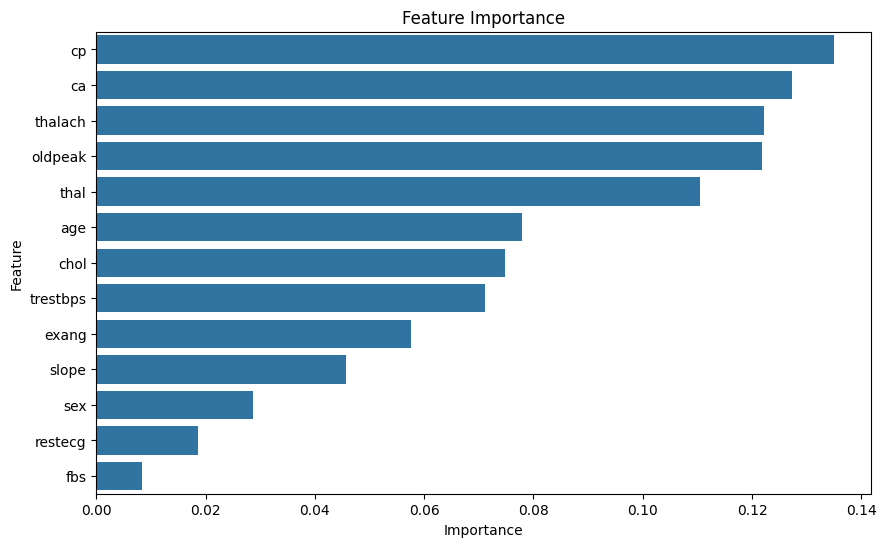

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=features
)

plt.title("Feature Importance")

plt.show()

## Conclusion

This project successfully developed a machine learning-based heart disease risk prediction system using clinical patient data.

Among the implemented models, Random Forest achieved the highest performance with an accuracy of 98.5%.

The analysis identified chest pain type, number of major vessels, maximum heart rate, and ST depression as major predictors of cardiovascular disease risk.

This project demonstrates the application of machine learning techniques in healthcare data analysis and predictive modeling.

In [48]:
import pickle

In [49]:
pickle.dump(rf_model, open('heart_model.pkl', 'wb'))

In [50]:
import os

os.listdir()

['.config', 'heart.csv', 'heart_model.pkl', 'sample_data']

In [55]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load trained model
model = pickle.load(open('heart_model.pkl', 'rb'))

# Title
st.title("Heart Disease Risk Predictor")

st.write("Enter patient clinical details below:")

# User Inputs
age = st.slider("Age", 20, 100, 50)

sex = st.selectbox(
    "Sex",
    [0, 1]
)

cp = st.slider("Chest Pain Type (cp)", 0, 3, 1)

trestbps = st.slider(
    "Resting Blood Pressure",
    80,
    200,
    120
)

chol = st.slider(
    "Cholesterol",
    100,
    600,
    200
)

fbs = st.selectbox(
    "Fasting Blood Sugar",
    [0, 1]
)

restecg = st.slider(
    "Resting ECG",
    0,
    2,
    1
)

thalach = st.slider(
    "Maximum Heart Rate",
    60,
    220,
    150
)

exang = st.selectbox(
    "Exercise Induced Angina",
    [0, 1]
)

oldpeak = st.slider(
    "Oldpeak",
    0.0,
    6.0,
    1.0
)

slope = st.slider(
    "Slope",
    0,
    2,
    1
)

ca = st.slider(
    "Number of Major Vessels",
    0,
    4,
    0
)

thal = st.slider(
    "Thal",
    0,
    3,
    1
)

# Create input array
input_data = np.array([
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
]).reshape(1, -1)

# Prediction Button
if st.button("Predict Heart Disease Risk"):

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("High Risk of Heart Disease Detected")
    else:
        st.success("Low Risk of Heart Disease")

Overwriting app.py
